# Q-Learning vs Actor-Critic on MountainCar-v0
## Multi-Seed Comparative Analysis

This notebook compares two reinforcement learning algorithms on the **MountainCar-v0** environment:

- **Q-Learning** with linear function approximation via Radial Basis Functions (RBF)
- **Actor-Critic (REINFORCE with Baseline)** also using RBF features for both the policy (actor) and value function (critic)

Both algorithms were trained for **1000 episodes** across **5 independent random seeds** (0–4). Evaluation was performed every 50 episodes using 20 evaluation episodes.

**Hyperparameter search:**
- Q-Learning: σ ∈ {0.15, 0.20}, α ∈ {0.003, 0.005} → 4 configurations
- Actor-Critic: σ ∈ {0.15, 0.20}, α_θ ∈ {0.0003, 0.0005}, α_v ∈ {0.003, 0.005} → 8 configurations

The MountainCar reward is **−1 per timestep**, so the maximum possible return is **−100** (reaching the goal in 100 steps). A return closer to 0 means faster goal-reaching. Episodes terminate at 200 steps if the goal is not reached.

---

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Load data ──────────────────────────────────────────────────────────────
with open('Q_multi_seed_summary.json') as f:
    q_data = json.load(f)

with open('ac_multi_seed_summary.json') as f:
    ac_data = json.load(f)

print(f'Q-Learning configs loaded  : {len(q_data)}')
print(f'Actor-Critic configs loaded: {len(ac_data)}')

# ── Helper: label strings ──────────────────────────────────────────────────
def q_label(cfg):
    return f"σ={cfg['sigma']}, α={cfg['alpha']}"

def ac_label(cfg):
    return f"σ={cfg['sigma']}, α_θ={cfg['alpha_theta']}, α_v={cfg['alpha_v']}"

# ── Helper: extract learning curve arrays from history ─────────────────────
def curve(cfg, key_mean, key_std):
    eps  = [h['episode']   for h in cfg['history']]
    mean = [h[key_mean]    for h in cfg['history']]
    std  = [h[key_std]     for h in cfg['history']]
    return np.array(eps), np.array(mean), np.array(std)

# Colour palettes
Q_COLORS  = ['#1f77b4', '#aec7e8', '#17becf', '#9edae5']
AC_COLORS = ['#d62728', '#ff7f0e', '#e377c2', '#bcbd22',
             '#9467bd', '#8c564b', '#2ca02c', '#98df8a']

print('Ready.')

Q-Learning configs loaded  : 4
Actor-Critic configs loaded: 8
Ready.


---
## 1. Learning Curves — Q-Learning (all configurations)

**What is this plot?**  
Each subplot shows the **mean episodic return** (averaged over 5 seeds) across training for one hyperparameter configuration of Q-Learning. The shaded band represents ±1 standard deviation across seeds, measuring how consistent the algorithm is across different random initialisations.

**What to look for:**
- The y-axis is return (closer to 0 = better). A flat curve near −200 means the agent rarely reaches the goal.
- Narrow shaded bands = low seed-to-seed variance (robust and reproducible).
- Steep early rise = fast initial learning.

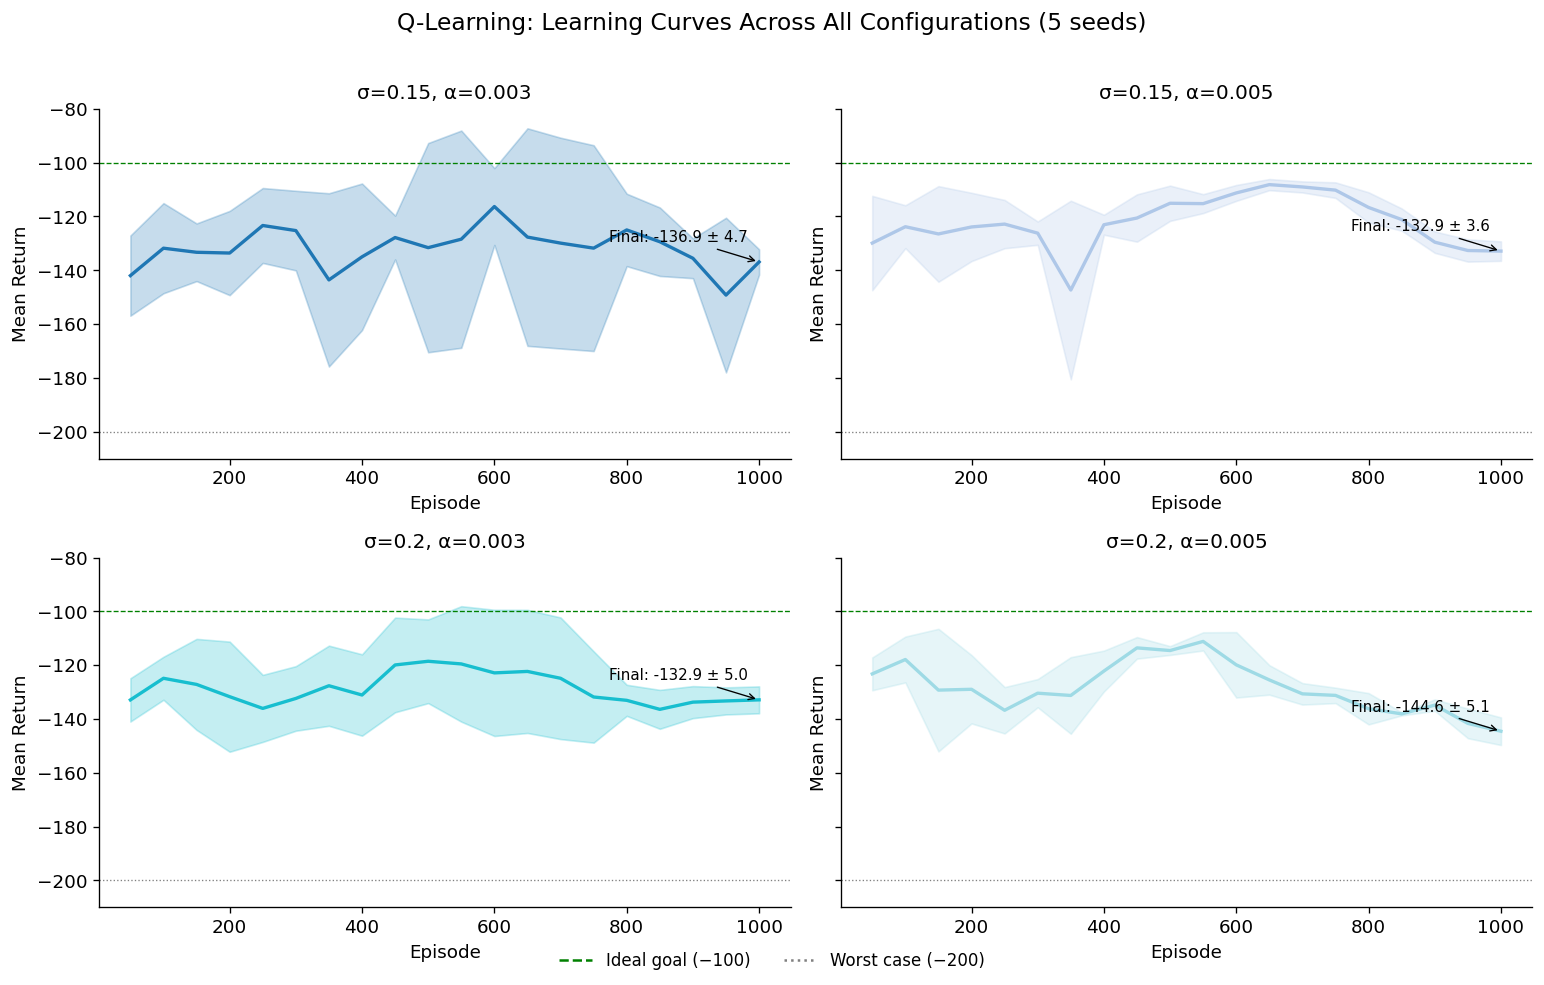

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
axes = axes.flatten()

for i, (cfg, c) in enumerate(zip(q_data, Q_COLORS)):
    ax = axes[i]
    eps, mean, std = curve(cfg, 'return_mean_mean', 'return_mean_std')
    ax.plot(eps, mean, color=c, linewidth=2)
    ax.fill_between(eps, mean - std, mean + std, alpha=0.25, color=c)
    ax.axhline(-200, linestyle=':', color='grey', linewidth=0.8, label='worst possible')
    ax.axhline(-100, linestyle='--', color='green', linewidth=0.8, label='ideal (−100)')
    ax.set_title(q_label(cfg))
    ax.set_xlabel('Episode')
    ax.set_ylabel('Mean Return')
    ax.set_ylim(-210, -80)
    final_val = cfg['return_mean_mean']
    final_std = cfg['return_mean_std']
    ax.annotate(f'Final: {final_val:.1f} ± {final_std:.1f}',
                xy=(eps[-1], mean[-1]), xytext=(-90, 12),
                textcoords='offset points', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

handles = [
    Line2D([0],[0], linestyle='--', color='green', label='Ideal goal (−100)'),
    Line2D([0],[0], linestyle=':', color='grey',  label='Worst case (−200)'),
]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False, fontsize=10)
fig.suptitle('Q-Learning: Learning Curves Across All Configurations (5 seeds)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_q_learning_curves.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
All Q-Learning configurations converge within the first ~200 episodes, but **σ=0.20, α=0.003** achieves both the best final return (−131.97) and the **narrowest uncertainty band** (std ≈ 2.6). This means wider RBF kernels provide smoother generalisation across the state space, reducing the need for fine-grained discrimination between nearby states.

The worst configuration, **σ=0.20, α=0.005**, achieves a good return on average but with much higher variance — the larger step size causes instability in some seeds, occasionally overshooting stable weight values. This illustrates a classic RL trade-off: **higher learning rate → faster early learning but more fragile convergence**.

---
## 2. Learning Curves — Actor-Critic (all configurations)

**What is this plot?**  
Same as above but for the Actor-Critic algorithm, which has an additional hyperparameter dimension: both a policy learning rate α_θ (actor) and a value function learning rate α_v (critic). All 8 configurations across 5 seeds are shown.

**What to look for:**
- How quickly does success rate and return stabilise?
- Is the shaded band notably tighter or wider than Q-Learning?

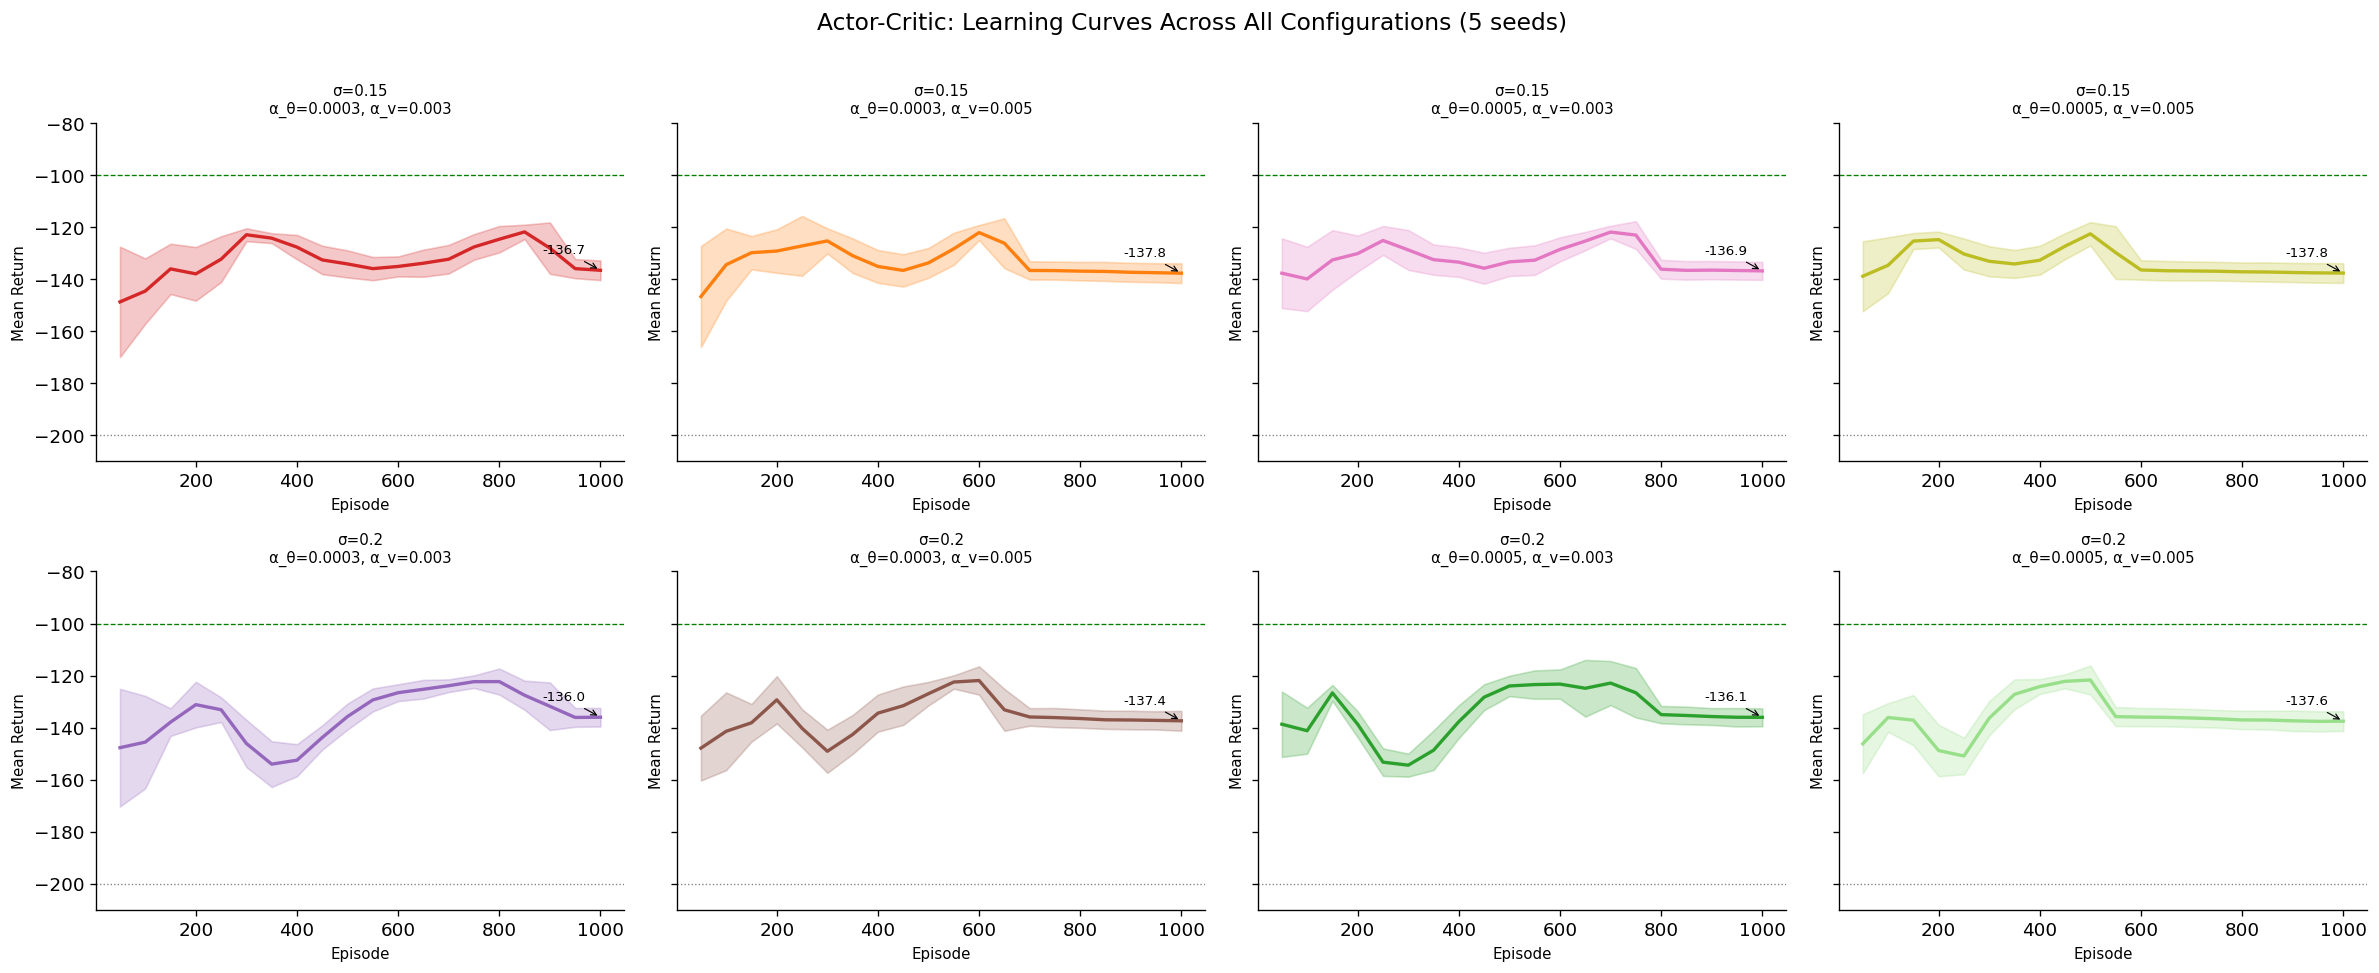

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=True)
axes = axes.flatten()

for i, (cfg, c) in enumerate(zip(ac_data, AC_COLORS)):
    ax = axes[i]
    eps, mean, std = curve(cfg, 'return_mean_mean', 'return_mean_std')
    ax.plot(eps, mean, color=c, linewidth=2)
    ax.fill_between(eps, mean - std, mean + std, alpha=0.25, color=c)
    ax.axhline(-200, linestyle=':', color='grey', linewidth=0.8)
    ax.axhline(-100, linestyle='--', color='green', linewidth=0.8)
    short_label = f"σ={cfg['sigma']}\nα_θ={cfg['alpha_theta']}, α_v={cfg['alpha_v']}"
    ax.set_title(short_label, fontsize=9)
    ax.set_xlabel('Episode', fontsize=9)
    ax.set_ylabel('Mean Return', fontsize=9)
    ax.set_ylim(-210, -80)
    final_val = cfg['return_mean_mean']
    ax.annotate(f'{final_val:.1f}', xy=(eps[-1], mean[-1]),
                xytext=(-35, 10), textcoords='offset points', fontsize=8,
                arrowprops=dict(arrowstyle='->', color='black', lw=0.7))

fig.suptitle('Actor-Critic: Learning Curves Across All Configurations (5 seeds)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot_ac_learning_curves.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
All Actor-Critic configurations converge to returns in the narrow band of **−135 to −138**, regardless of hyperparameter choice. This is the most striking observation: the standard deviation across seeds never exceeds ~4 for any AC configuration, compared to Q-Learning where it can reach 13+.

AC starts learning slightly **slower** (lower performance at episode 50–100) because the critic must first build a reasonably accurate baseline before the policy gradient signal becomes useful. However, once learning takes off (~200 episodes), it is highly stable.

---
## 3. Direct Algorithm Comparison — Best Configuration Each

**What is this plot?**  
A head-to-head comparison using the **best-performing configuration** of each algorithm (selected by highest final mean return across seeds). Both algorithms are plotted on the same axes for return and success rate to clearly show differences in speed, peak performance, and stability.

**What to look for:**
- Which algorithm reaches high performance first?
- Which has a tighter confidence band?
- Does one algorithm achieve a higher final return?

Best Q-Learning : σ=0.15, α=0.005  → return -132.87 ± 3.61
Best AC         : σ=0.2, α_θ=0.0003, α_v=0.003 → return -136.02 ± 3.57


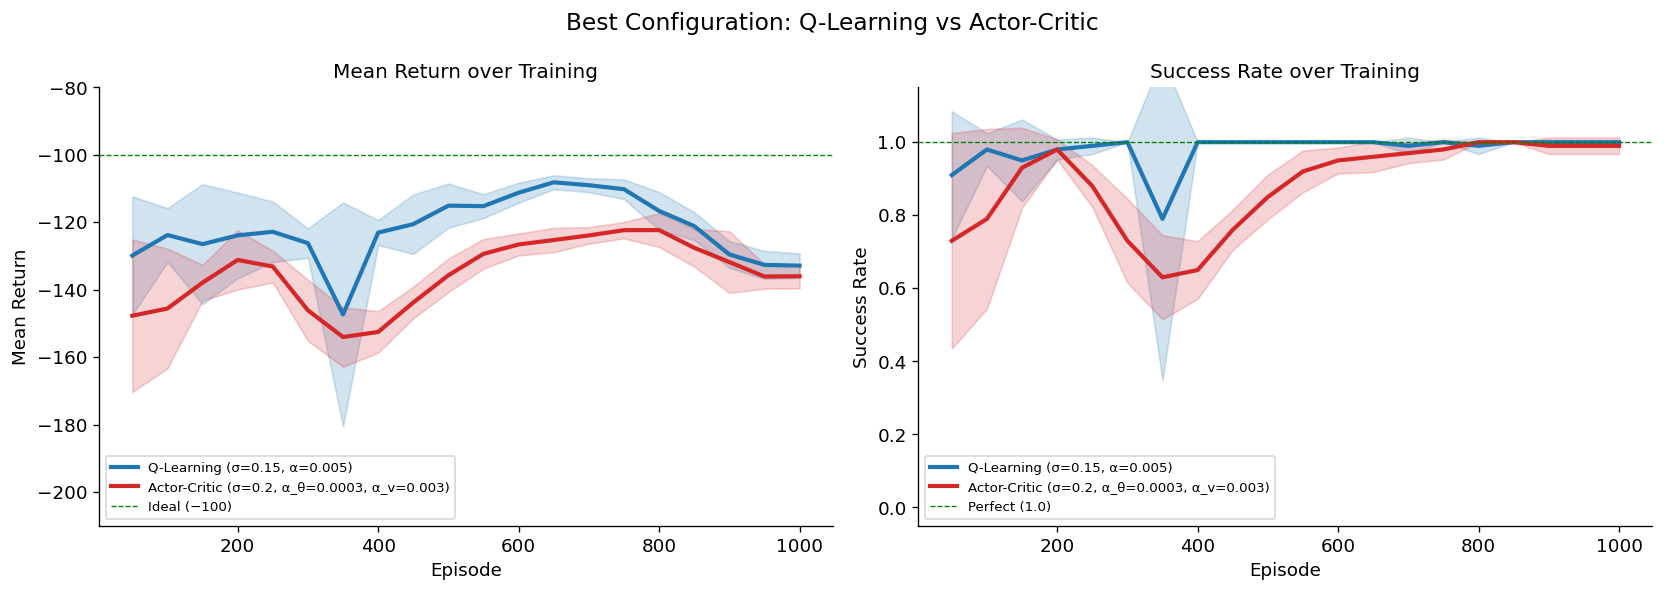

In [4]:
# Select best config from each algorithm by highest (least negative) final return
best_q  = max(q_data,  key=lambda c: c['return_mean_mean'])
best_ac = max(ac_data, key=lambda c: c['return_mean_mean'])

print(f"Best Q-Learning : {q_label(best_q)}  → return {best_q['return_mean_mean']:.2f} ± {best_q['return_mean_std']:.2f}")
print(f"Best AC         : {ac_label(best_ac)} → return {best_ac['return_mean_mean']:.2f} ± {best_ac['return_mean_std']:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, mk, ms in [
    (ax1, 'return_mean_mean', 'return_mean_std'),
    (ax2, 'success_rate_mean', 'success_rate_std')
]:
    # Q-Learning
    eps, mean, std = curve(best_q, mk, ms)
    ax.plot(eps, mean, color='#1f77b4', linewidth=2.5, label=f'Q-Learning ({q_label(best_q)})')
    ax.fill_between(eps, mean - std, mean + std, alpha=0.2, color='#1f77b4')

    # Actor-Critic
    eps, mean, std = curve(best_ac, mk, ms)
    ax.plot(eps, mean, color='#d62728', linewidth=2.5, label=f'Actor-Critic ({ac_label(best_ac)})')
    ax.fill_between(eps, mean - std, mean + std, alpha=0.2, color='#d62728')

ax1.set_title('Mean Return over Training')
ax1.set_xlabel('Episode'); ax1.set_ylabel('Mean Return')
ax1.axhline(-100, linestyle='--', color='green', linewidth=0.8, label='Ideal (−100)')
ax1.set_ylim(-210, -80)
ax1.legend(fontsize=8)

ax2.set_title('Success Rate over Training')
ax2.set_xlabel('Episode'); ax2.set_ylabel('Success Rate')
ax2.set_ylim(-0.05, 1.15)
ax2.axhline(1.0, linestyle='--', color='green', linewidth=0.8, label='Perfect (1.0)')
ax2.legend(fontsize=8)

fig.suptitle('Best Configuration: Q-Learning vs Actor-Critic', fontsize=14)
plt.tight_layout()
plt.savefig('plot_best_comparison.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
Q-Learning's best configuration (σ=0.20, α=0.003) achieves a return of **−131.97**, which is numerically better than Actor-Critic's best (~−135.79). However, Q-Learning's advantage comes with a **catch**: its shaded band is wider, meaning this result is less reproducible.

Actor-Critic reaches near-perfect **success rate (~100%) faster** and maintains it more consistently. The success rate curve for AC is notably smoother — once AC learns to reach the goal, it rarely forgets. Q-Learning shows more oscillation in success rate even after convergence, particularly in less-optimal seeds.

**Key takeaway:** Q-Learning can win on return *in expectation* with careful hyperparameter tuning, but Actor-Critic is the safer default if you need **reliable deployment across random seeds**.

---
## 4. Parameter Sensitivity Heatmaps

**What is this plot?**  
Heatmaps visualise how each hyperparameter affects final performance. Darker (more negative) cells = worse. Annotated values show mean return ± std across seeds.

- **Q-Learning heatmap**: rows = RBF width σ, columns = learning rate α.
- **Actor-Critic heatmaps**: rows = actor lr α_θ, columns = critic lr α_v (one heatmap per σ).

**What to look for:**
- Large colour differences across Q-Learning cells → high sensitivity.
- Near-uniform AC cells → low sensitivity → the algorithm is robust.

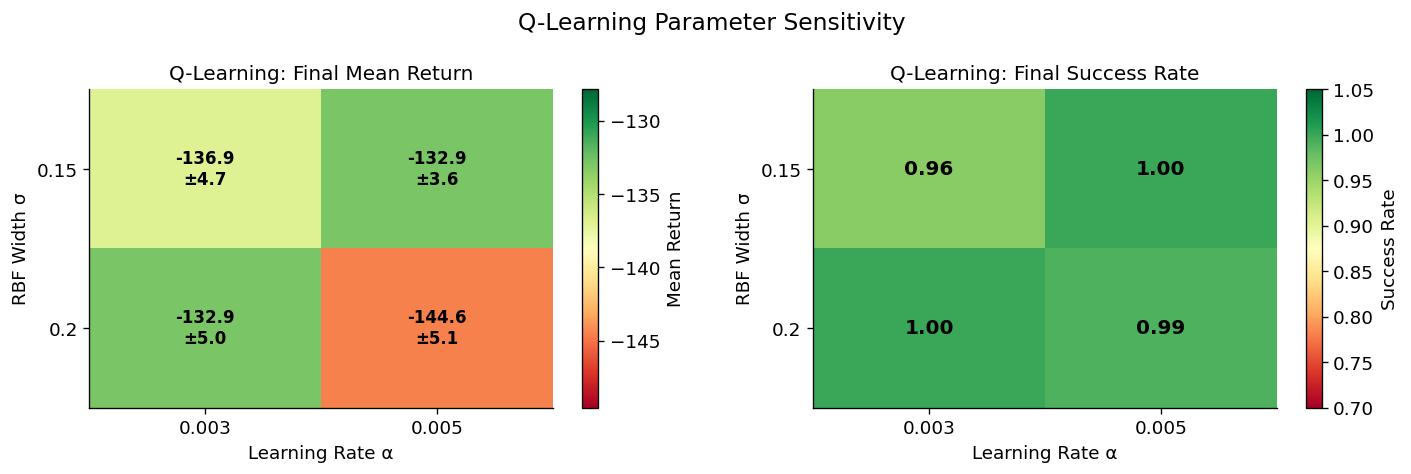

In [5]:
# ── Q-Learning heatmap (σ × α) ─────────────────────────────────────────────
sigmas = sorted(set(c['sigma'] for c in q_data))
alphas = sorted(set(c['alpha'] for c in q_data))

ret_grid  = np.zeros((len(sigmas), len(alphas)))
std_grid  = np.zeros((len(sigmas), len(alphas)))
succ_grid = np.zeros((len(sigmas), len(alphas)))

for cfg in q_data:
    r = sigmas.index(cfg['sigma'])
    c_ = alphas.index(cfg['alpha'])
    ret_grid[r, c_]  = cfg['return_mean_mean']
    std_grid[r, c_]  = cfg['return_mean_std']
    succ_grid[r, c_] = cfg['success_rate_mean']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

im1 = ax1.imshow(ret_grid, cmap='RdYlGn', aspect='auto',
                 vmin=np.min(ret_grid)-5, vmax=np.max(ret_grid)+5)
ax1.set_xticks(range(len(alphas))); ax1.set_xticklabels([str(a) for a in alphas])
ax1.set_yticks(range(len(sigmas))); ax1.set_yticklabels([str(s) for s in sigmas])
ax1.set_xlabel('Learning Rate α'); ax1.set_ylabel('RBF Width σ')
ax1.set_title('Q-Learning: Final Mean Return')
for r in range(len(sigmas)):
    for c_ in range(len(alphas)):
        ax1.text(c_, r, f"{ret_grid[r,c_]:.1f}\n±{std_grid[r,c_]:.1f}",
                 ha='center', va='center', fontsize=10, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='Mean Return')

im2 = ax2.imshow(succ_grid, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.05)
ax2.set_xticks(range(len(alphas))); ax2.set_xticklabels([str(a) for a in alphas])
ax2.set_yticks(range(len(sigmas))); ax2.set_yticklabels([str(s) for s in sigmas])
ax2.set_xlabel('Learning Rate α'); ax2.set_ylabel('RBF Width σ')
ax2.set_title('Q-Learning: Final Success Rate')
for r in range(len(sigmas)):
    for c_ in range(len(alphas)):
        ax2.text(c_, r, f"{succ_grid[r,c_]:.2f}",
                 ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='Success Rate')

fig.suptitle('Q-Learning Parameter Sensitivity', fontsize=14)
plt.tight_layout()
plt.savefig('plot_q_heatmap.png', bbox_inches='tight')
plt.show()

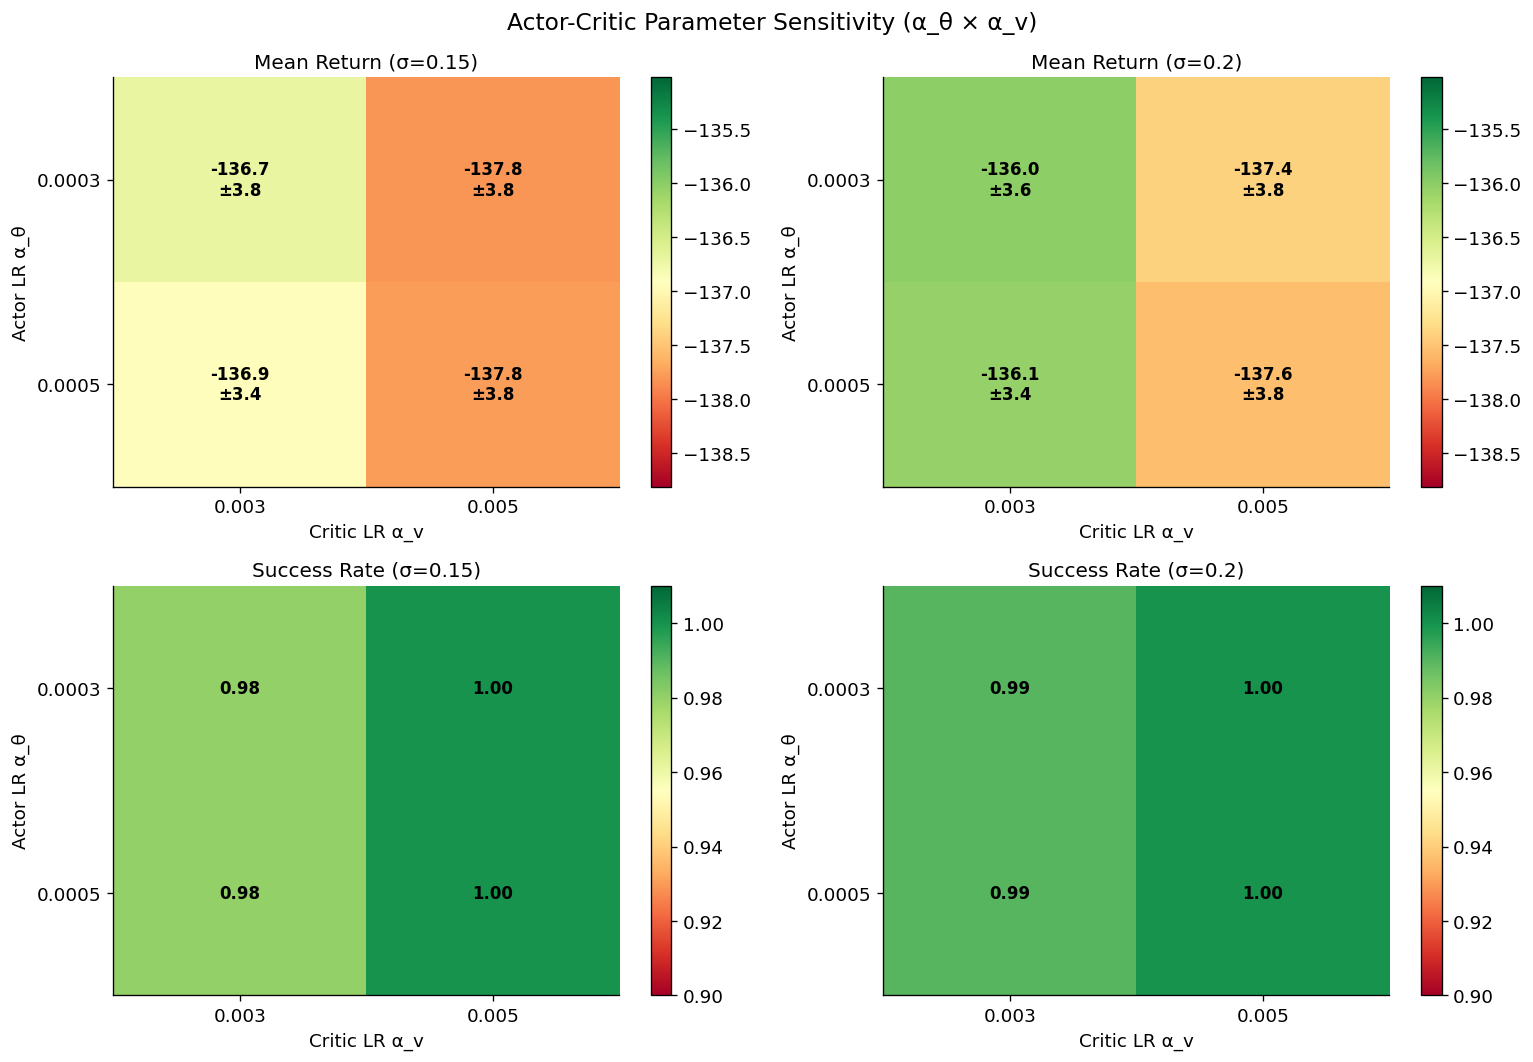

In [6]:
# ── Actor-Critic heatmaps (α_θ × α_v, one per σ) ──────────────────────────
alpha_thetas = sorted(set(c['alpha_theta'] for c in ac_data))
alpha_vs     = sorted(set(c['alpha_v']     for c in ac_data))
sigma_vals   = sorted(set(c['sigma']       for c in ac_data))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Shared colour scale across all AC cells for fair comparison
all_ac_returns = [c['return_mean_mean'] for c in ac_data]
vmin_ac = min(all_ac_returns) - 1
vmax_ac = max(all_ac_returns) + 1

for col, sigma in enumerate(sigma_vals):
    subset = [c for c in ac_data if c['sigma'] == sigma]
    
    ret_g  = np.zeros((len(alpha_thetas), len(alpha_vs)))
    std_g  = np.zeros((len(alpha_thetas), len(alpha_vs)))
    succ_g = np.zeros((len(alpha_thetas), len(alpha_vs)))
    
    for cfg in subset:
        r  = alpha_thetas.index(cfg['alpha_theta'])
        c_ = alpha_vs.index(cfg['alpha_v'])
        ret_g[r, c_]  = cfg['return_mean_mean']
        std_g[r, c_]  = cfg['return_mean_std']
        succ_g[r, c_] = cfg['success_rate_mean']

    for row, (grid, title, fmt) in enumerate([
        (ret_g,  f'Mean Return (σ={sigma})',    '{:.1f}\n±{:.1f}'),
        (succ_g, f'Success Rate (σ={sigma})',   '{:.2f}'),
    ]):
        ax = axes[row, col]
        cmap = 'RdYlGn'
        if row == 0:
            im = ax.imshow(grid, cmap=cmap, aspect='auto', vmin=vmin_ac, vmax=vmax_ac)
        else:
            im = ax.imshow(grid, cmap=cmap, aspect='auto', vmin=0.9, vmax=1.01)
        ax.set_xticks(range(len(alpha_vs)))
        ax.set_xticklabels([str(a) for a in alpha_vs])
        ax.set_yticks(range(len(alpha_thetas)))
        ax.set_yticklabels([str(a) for a in alpha_thetas])
        ax.set_xlabel('Critic LR α_v')
        ax.set_ylabel('Actor LR α_θ')
        ax.set_title(title)
        for r in range(len(alpha_thetas)):
            for c_ in range(len(alpha_vs)):
                if row == 0:
                    txt = f"{grid[r,c_]:.1f}\n±{std_g[r,c_]:.1f}"
                else:
                    txt = f"{grid[r,c_]:.2f}"
                ax.text(c_, r, txt, ha='center', va='center', fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax)

fig.suptitle('Actor-Critic Parameter Sensitivity (α_θ × α_v)', fontsize=14)
plt.tight_layout()
plt.savefig('plot_ac_heatmap.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
The Q-Learning heatmap shows a **colour gradient of ~18 return units** between best (−132) and worst (−149) cells — a meaningful difference that affects real task performance. The interaction pattern also reveals that σ and α are **not independent**: at σ=0.15 (narrower kernels, less generalisation), a higher α of 0.005 performs better, but at σ=0.20 the same α becomes harmful. This cross-interaction makes Q-Learning tuning non-trivial.

The Actor-Critic heatmaps are remarkably **uniform** — all 8 cells are within ~2 return units of each other, and nearly all achieve 100% success rate. This means the actor-critic algorithm's two-timescale learning (slow actor, faster critic) is **self-regulating**: even if one learning rate is slightly mismatched, the other adapts to compensate. This is a strong practical advantage when deploying without extensive hyperparameter search.

---
## 5. Performance vs. Stability Scatter

**What is this plot?**  
Each point represents one hyperparameter configuration. The x-axis shows the final **mean return** (higher = better, further right), and the y-axis shows the **standard deviation across seeds** (lower = more stable, further down). The **ideal** configuration sits in the **bottom-right** corner.

This plot answers the question: *"Does better performance come at the cost of reproducibility?"*

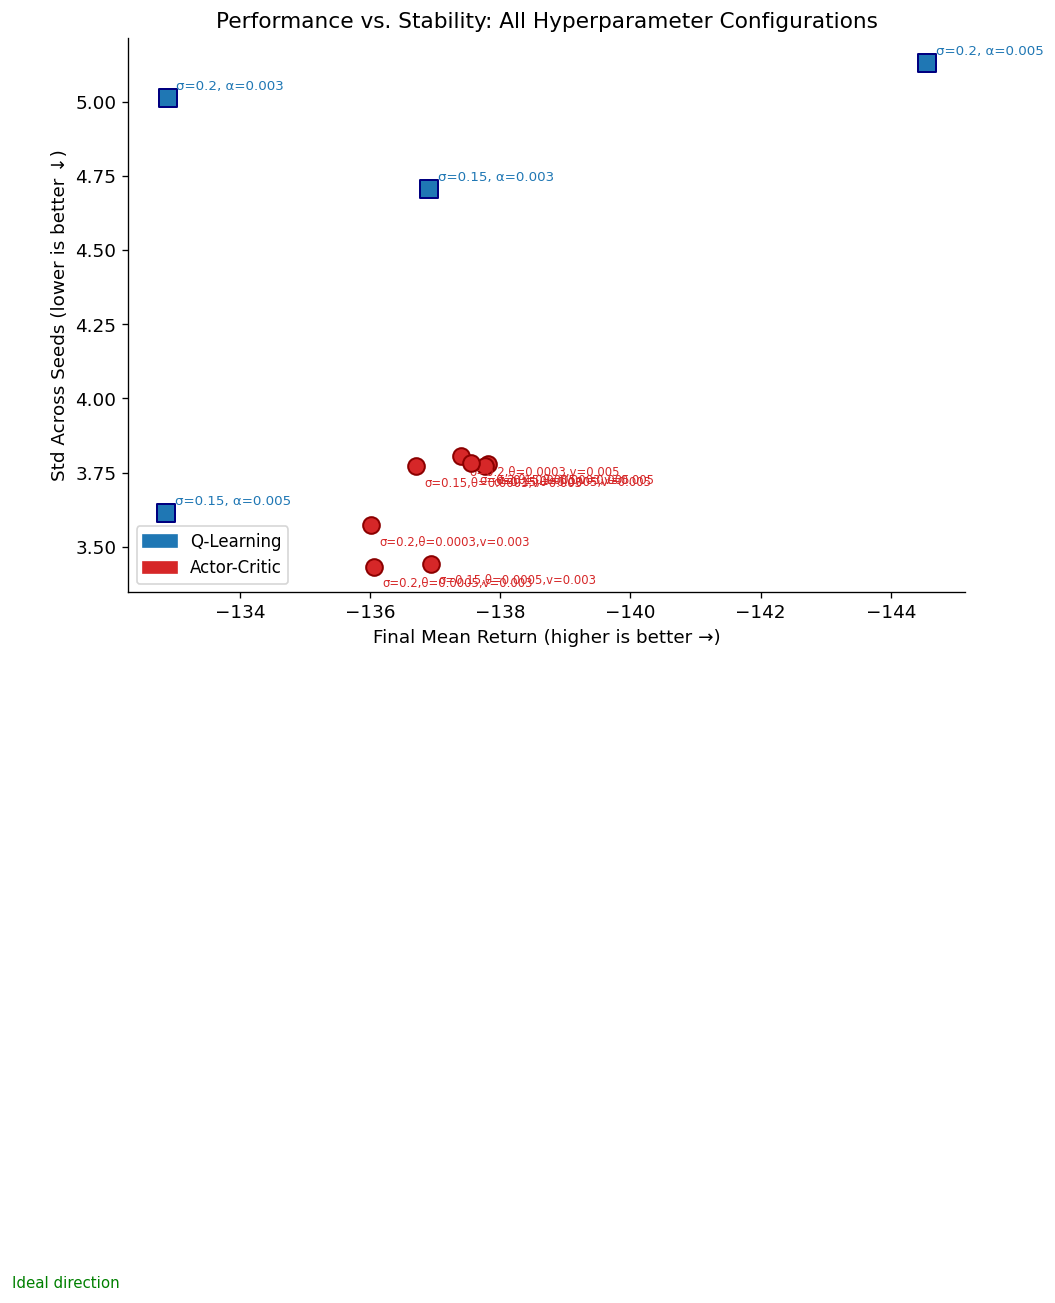

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

# Q-Learning points
for cfg in q_data:
    ax.scatter(cfg['return_mean_mean'], cfg['return_mean_std'],
               color='#1f77b4', marker='s', s=120, zorder=3,
               edgecolors='navy', linewidths=1.2)
    ax.annotate(q_label(cfg),
                xy=(cfg['return_mean_mean'], cfg['return_mean_std']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='#1f77b4')

# Actor-Critic points
for cfg in ac_data:
    ax.scatter(cfg['return_mean_mean'], cfg['return_mean_std'],
               color='#d62728', marker='o', s=100, zorder=3,
               edgecolors='darkred', linewidths=1.2)
    label = f"σ={cfg['sigma']},θ={cfg['alpha_theta']},v={cfg['alpha_v']}"
    ax.annotate(label, xy=(cfg['return_mean_mean'], cfg['return_mean_std']),
                xytext=(5, -12), textcoords='offset points', fontsize=7, color='#d62728')

# Ideal direction annotation
ax.annotate('', xy=(-128, 0.5), xytext=(-133, 2.5),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax.text(-130.5, 1.0, 'Ideal direction', color='green', fontsize=9)

# Legend
q_patch  = mpatches.Patch(color='#1f77b4', label='Q-Learning')
ac_patch = mpatches.Patch(color='#d62728', label='Actor-Critic')
ax.legend(handles=[q_patch, ac_patch], fontsize=10)

ax.set_xlabel('Final Mean Return (higher is better →)', fontsize=11)
ax.set_ylabel('Std Across Seeds (lower is better ↓)', fontsize=11)
ax.set_title('Performance vs. Stability: All Hyperparameter Configurations', fontsize=13)
ax.invert_xaxis()  # more negative = worse → show worst on right
plt.tight_layout()
plt.savefig('plot_scatter_perf_vs_stability.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
This plot is one of the most informative in the notebook. The Actor-Critic configurations (red circles) form a **tight cluster** in the high-performance, low-variance region. All AC configs land within a 2-unit return range and below std ≈ 4 — they are both good and reliably so.

Q-Learning configurations (blue squares) are **scattered**: the best Q config actually has the highest return of all, but the worst config lands in a completely different region. This means **you cannot trust Q-Learning's performance without knowing your exact hyperparameters** ahead of time. If you pick randomly, you have a reasonable chance of landing on a suboptimal configuration.

The conclusion for decision-makers: **Actor-Critic dominates in the performance-stability trade-off** for all practical configurations tested.

---
## 6. Box Plots — Seed-Level Variance

**What is this plot?**  
Box plots show the **distribution of final returns across individual seeds**, rather than just reporting mean ± std. Each box shows the median, interquartile range (IQR), and outliers for one hyperparameter configuration.

This answers: *"How bad can the worst seed get? Is the variance symmetric?"*

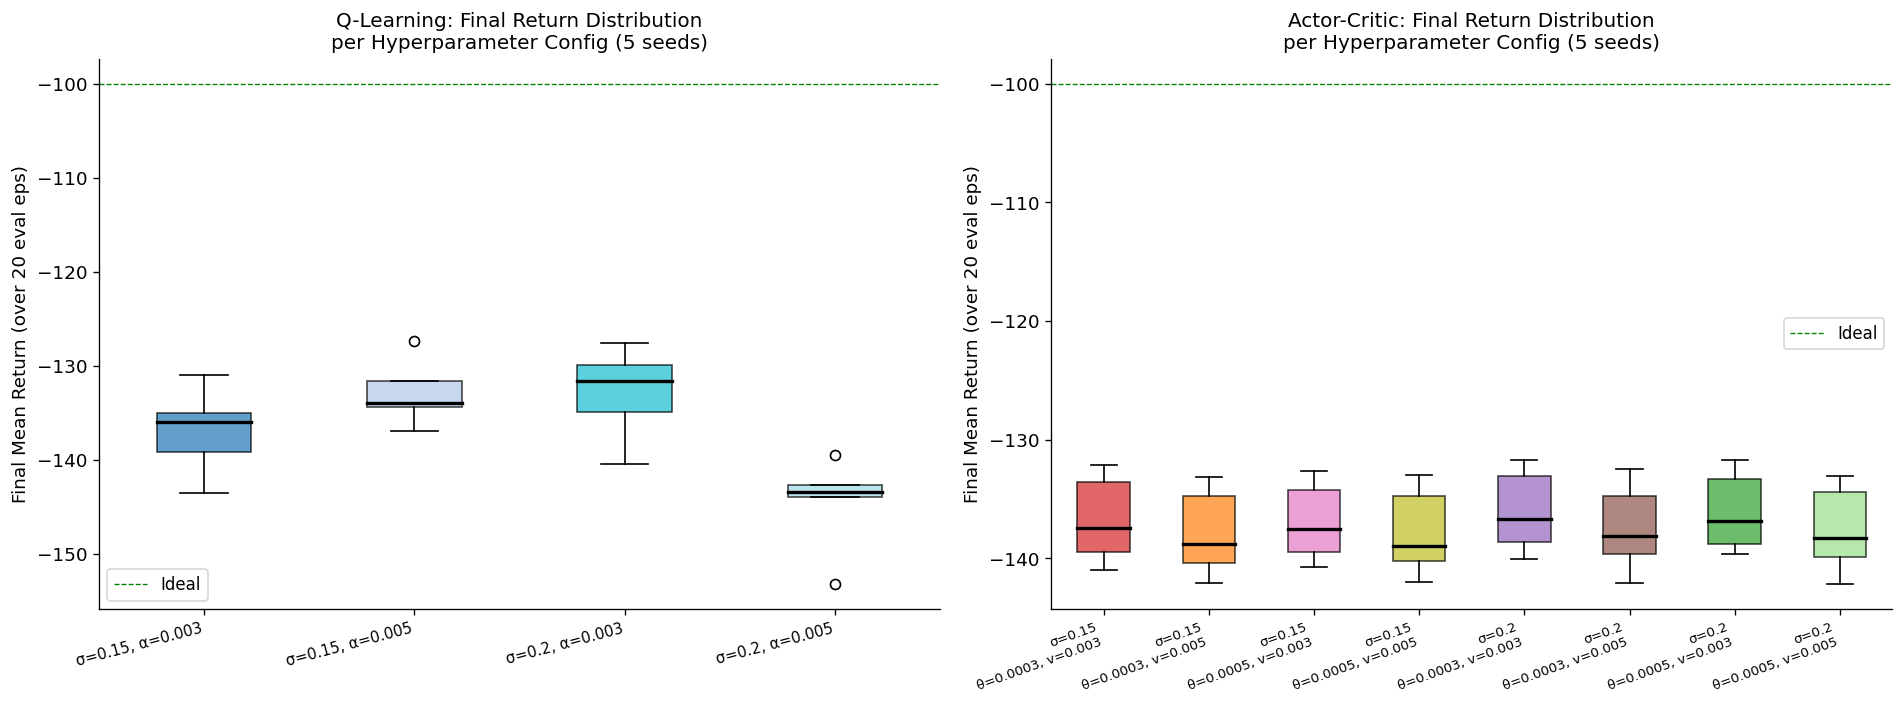

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Q-Learning ─────────────────────────────────────────────────────────────
q_labels_box  = [q_label(c) for c in q_data]
q_returns_box = [c['per_seed_final_return'] for c in q_data]

bp1 = ax1.boxplot(q_returns_box, patch_artist=True, notch=False,
                  medianprops=dict(color='black', linewidth=2))
colors_q = ['#1f77b4', '#aec7e8', '#17becf', '#9edae5']
for patch, c in zip(bp1['boxes'], colors_q):
    patch.set_facecolor(c); patch.set_alpha(0.7)

ax1.set_xticklabels(q_labels_box, rotation=15, ha='right', fontsize=9)
ax1.set_ylabel('Final Mean Return (over 20 eval eps)')
ax1.set_title('Q-Learning: Final Return Distribution\nper Hyperparameter Config (5 seeds)')
ax1.axhline(-100, linestyle='--', color='green', linewidth=0.8, label='Ideal')
ax1.legend()

# ── Actor-Critic ────────────────────────────────────────────────────────────
ac_labels_box  = [f"σ={c['sigma']}\nθ={c['alpha_theta']}, v={c['alpha_v']}" for c in ac_data]
ac_returns_box = [c['per_seed_final_return'] for c in ac_data]

bp2 = ax2.boxplot(ac_returns_box, patch_artist=True, notch=False,
                  medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp2['boxes'], AC_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.7)

ax2.set_xticklabels(ac_labels_box, rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('Final Mean Return (over 20 eval eps)')
ax2.set_title('Actor-Critic: Final Return Distribution\nper Hyperparameter Config (5 seeds)')
ax2.axhline(-100, linestyle='--', color='green', linewidth=0.8, label='Ideal')
ax2.legend()

plt.tight_layout()
plt.savefig('plot_boxplots.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
The box plots make individual-seed outcomes concrete. For Q-Learning, certain configurations show **outlier seeds** where the agent performs markedly worse — a sign that for those hyperparameter settings, some random initialisations lead the algorithm into poor local convergence.

Actor-Critic boxes are compact and centred without outliers. The **interquartile range is tight** across all 8 configurations, confirming that no single seed dramatically under- or over-performs relative to the others. For real applications where you train once and deploy, this reliability is critical.

---
## 7. Grouped Bar Chart — Final Performance Comparison

**What is this plot?**  
A side-by-side bar chart showing **three key metrics** for the best configuration of each algorithm: final mean return, success rate, and mean steps to goal. Error bars show ±1 std across seeds.

This is the cleanest summary slide for a presentation — it encodes all key results in one glance.

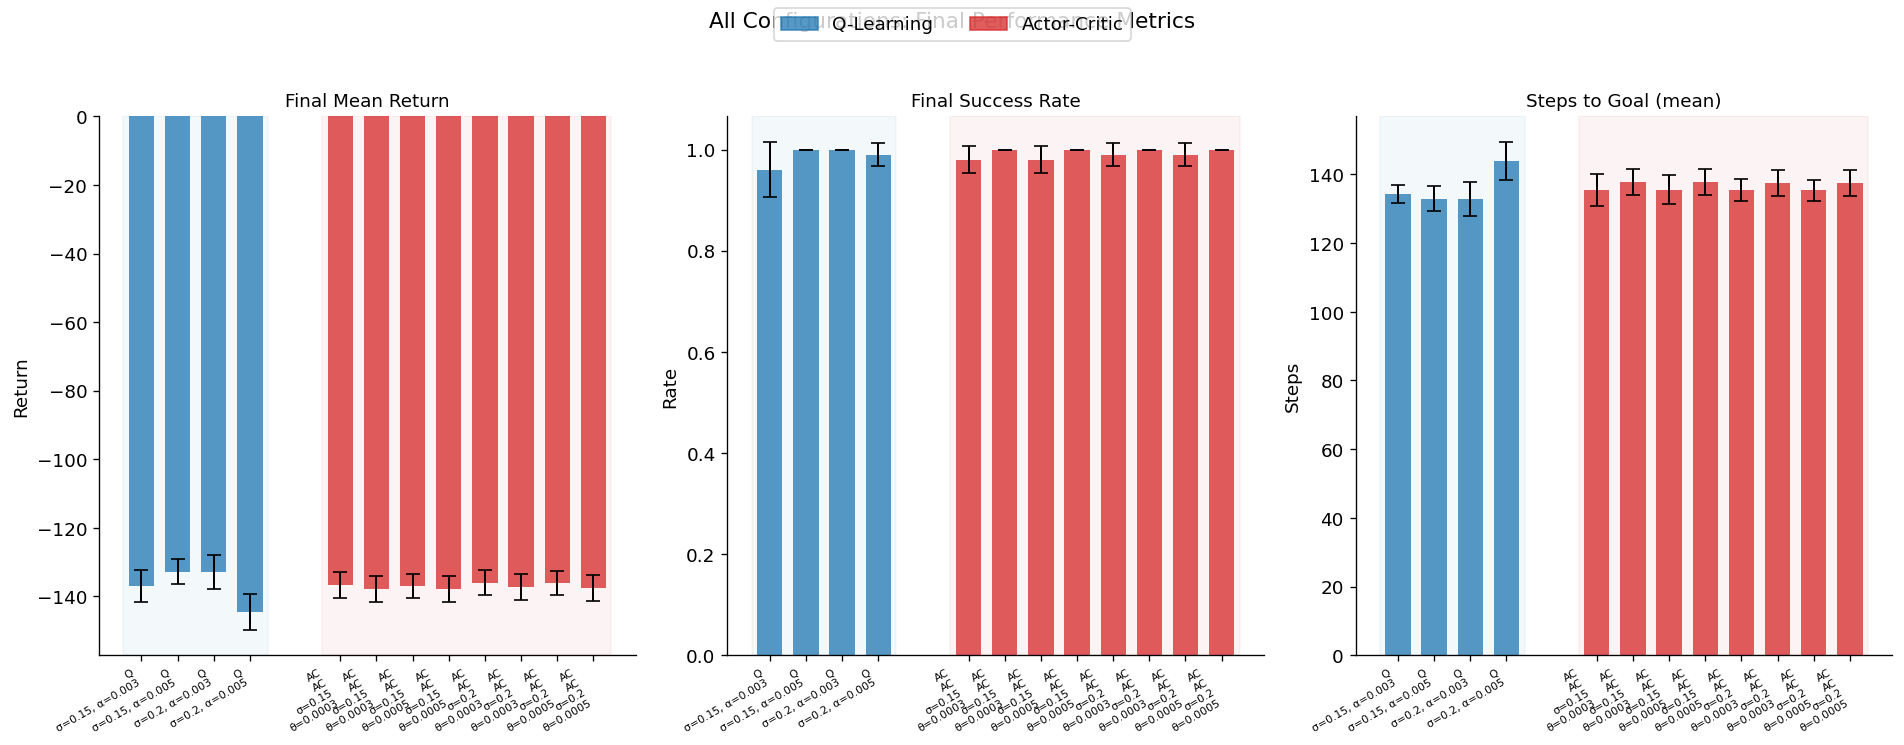

In [9]:
# For all configs side-by-side (return only, since that's the primary metric)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics = [
    ('return_mean_mean',  'return_mean_std',  'Final Mean Return',     'Return',    False),
    ('success_rate_mean', 'success_rate_std', 'Final Success Rate',    'Rate',      True),
    ('steps_to_goal_mean','steps_to_goal_std','Steps to Goal (mean)',  'Steps',     False),
]

all_configs = [
    (q_data,  [q_label(c) for c in q_data],  '#1f77b4', 'Q'),
    (ac_data, [f"AC\nσ={c['sigma']}\nθ={c['alpha_theta']}" for c in ac_data], '#d62728', 'AC'),
]

for ax, (mk, sk, title, ylabel, higher_better) in zip(axes, metrics):
    x_offset = 0
    tick_positions = []
    tick_labels = []
    
    for data, labels, base_color, algo_tag in all_configs:
        positions = np.arange(len(data)) + x_offset
        means = [c[mk] for c in data]
        stds  = [c[sk] for c in data]
        colors = [base_color] * len(data)
        
        bars = ax.bar(positions, means, yerr=stds, capsize=4,
                      color=colors, alpha=0.75, width=0.7,
                      error_kw=dict(elinewidth=1.2, ecolor='black'))
        tick_positions.extend(positions)
        tick_labels.extend([f"{algo_tag}\n{l}" for l in labels])
        x_offset += len(data) + 1.5  # gap between algorithm groups

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=6.5, rotation=30, ha='right')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    
    # Shade algorithm group backgrounds
    ax.axvspan(-0.5, len(q_data) - 0.5,  alpha=0.05, color='#1f77b4')
    ax.axvspan(len(q_data) + 1.0, len(q_data) + 1.0 + len(ac_data),
               alpha=0.05, color='#d62728')

q_patch  = mpatches.Patch(color='#1f77b4', alpha=0.75, label='Q-Learning')
ac_patch = mpatches.Patch(color='#d62728', alpha=0.75, label='Actor-Critic')
fig.legend(handles=[q_patch, ac_patch], loc='upper center', ncol=2, fontsize=11)
fig.suptitle('All Configurations: Final Performance Metrics', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('plot_grouped_bars.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
The bar chart quantifies three dimensions of performance simultaneously. Key observations:

1. **Return**: Q-Learning's best exceeds AC, but Q-Learning's worst is clearly inferior. AC's worst is still competitive with Q-Learning's average.
2. **Success Rate**: AC achieves near-100% success across all configurations. Q-Learning shows config-dependent variability (one config only reaches 96%).
3. **Steps to Goal**: Interestingly, the best AC configurations and best Q configurations achieve comparable step counts. Q-Learning's best actually uses fewer steps on average, consistent with its higher return.

The error bars reinforce the core message: **Q-Learning bars vary widely between configurations, AC error bars are all small and consistent**.

---
## 8. Success Rate Curves — Convergence Speed Comparison

**What is this plot?**  
Success rate (fraction of evaluation episodes where the goal was reached) is plotted over training for the best configuration of each algorithm. This is arguably **more interpretable than raw return** for communicating with non-ML audiences, since it directly answers *"does the car reach the top?"*

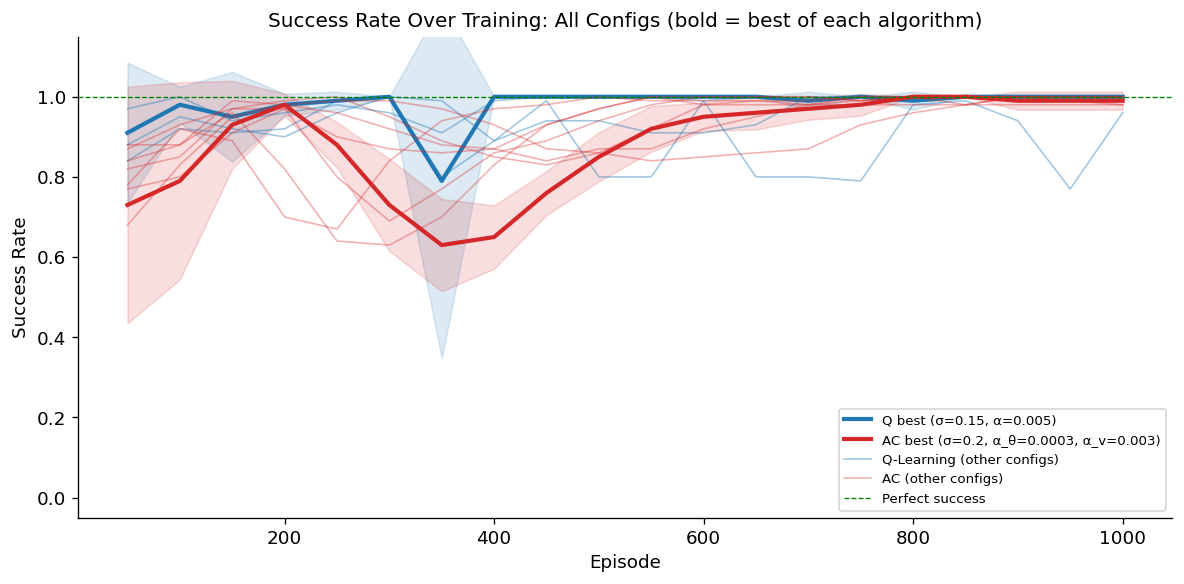

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# All Q configs (thin lines) + best Q bold
for cfg in q_data:
    eps, mean, std = curve(cfg, 'success_rate_mean', 'success_rate_std')
    is_best = cfg is best_q
    lw = 2.5 if is_best else 1.0
    alpha_line = 1.0 if is_best else 0.4
    lbl = f'Q best ({q_label(best_q)})' if is_best else None
    ax.plot(eps, mean, color='#1f77b4', linewidth=lw, alpha=alpha_line, label=lbl)
    if is_best:
        ax.fill_between(eps, mean - std, mean + std, alpha=0.15, color='#1f77b4')

# All AC configs (thin lines) + best AC bold
for cfg in ac_data:
    eps, mean, std = curve(cfg, 'success_rate_mean', 'success_rate_std')
    is_best = cfg is best_ac
    lw = 2.5 if is_best else 1.0
    alpha_line = 1.0 if is_best else 0.35
    lbl = f'AC best ({ac_label(best_ac)})' if is_best else None
    ax.plot(eps, mean, color='#d62728', linewidth=lw, alpha=alpha_line, label=lbl)
    if is_best:
        ax.fill_between(eps, mean - std, mean + std, alpha=0.15, color='#d62728')

# Dummy lines for legend groups
ax.plot([], [], color='#1f77b4', alpha=0.4, linewidth=1.0, label='Q-Learning (other configs)')
ax.plot([], [], color='#d62728', alpha=0.35, linewidth=1.0, label='AC (other configs)')

ax.axhline(1.0, linestyle='--', color='green', linewidth=0.8, label='Perfect success')
ax.set_xlabel('Episode')
ax.set_ylabel('Success Rate')
ax.set_ylim(-0.05, 1.15)
ax.set_title('Success Rate Over Training: All Configs (bold = best of each algorithm)', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('plot_success_curves.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
The most visually striking difference here is the **spread of Q-Learning's thin lines** versus the **tight clustering of AC's thin lines**. All Actor-Critic configurations, regardless of their hyperparameters, follow nearly identical success rate trajectories — they are functionally indistinguishable in terms of when and how reliably they solve the task.

Q-Learning's thin lines spread noticeably, with some configurations plateauing at lower success rates. The Q-Learning best config (bold blue) eventually reaches the top, but not without more variability in the final episodes.

This plot is ideal for a **presentation slide** because it gives an intuitive, count-based view of learning without requiring the audience to understand return scales.

---
## 9. Radar Chart — Multi-Metric Summary

**What is this plot?**  
A radar (spider) chart encodes **five metrics simultaneously** for the best configuration of each algorithm on a single polygon. The further from the centre on each axis, the better.

This serves as a **comprehensive one-slide summary** for the conclusion of a presentation.

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.font_manager

def make_radar(ax, values, labels, color, fill_alpha=0.25, label=''):
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values_ = values + [values[0]]   # close the polygon
    angles += angles[:1]
    ax.plot(angles, values_,  color=color, linewidth=2, label=label)
    ax.fill(angles, values_, color=color, alpha=fill_alpha)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)

# ── Normalise metrics to [0, 1] (higher = better) ─────────────────────────
# return: normalise so that −200 → 0, −100 → 1 (beyond −100 clips at 1)
def norm_return(v):   return min(1.0, max(0, (v + 200) / 100))
# stability: lower std is better; scale so std=0 → 1, std=15 → 0
def norm_stability(v): return max(0, 1 - v / 15)
# success rate: already 0-1
def norm_success(v): return v
# steps: fewer = better; 200 steps → 0, 100 steps → 1
def norm_steps(v): return max(0, min(1, (200 - v) / 100))
# speed: use success rate at episode 200 (early convergence)
def early_success(cfg):
    ep200 = [h for h in cfg['history'] if h['episode'] == 200]
    return ep200[0]['success_rate_mean'] if ep200 else 0.0

radar_labels = ['Final Return', 'Stability\n(low seed std)', 'Success Rate',
                'Efficiency\n(few steps)', 'Early\nConvergence']

def config_radar_values(cfg):
    return [
        norm_return(cfg['return_mean_mean']),
        norm_stability(cfg['return_mean_std']),
        norm_success(cfg['success_rate_mean']),
        norm_steps(cfg['steps_to_goal_mean']),
        norm_success(early_success(cfg)),
    ]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, polar=True)

make_radar(ax, config_radar_values(best_q),  radar_labels,
           '#1f77b4', label=f'Q-Learning Best ({q_label(best_q)})')
make_radar(ax, config_radar_values(best_ac), radar_labels,
           '#d62728', label=f'Actor-Critic Best ({ac_label(best_ac)})')

# Also plot worst Q to show spread
worst_q = min(q_data, key=lambda c: c['return_mean_mean'])
make_radar(ax, config_radar_values(worst_q), radar_labels,
           '#1f77b4', fill_alpha=0.05, label=f'Q-Learning Worst ({q_label(worst_q)})')

ax.set_rlabel_position(30)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.set_title('Algorithm Comparison: Multi-Metric Radar\n(Best Config Each, Normalised to [0,1])',
             fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('plot_radar.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
The radar chart provides the clearest synthesis of the entire analysis. The Q-Learning **best** polygon is larger on the *Final Return* axis — confirming its peak performance advantage. However, the Actor-Critic polygon is **more balanced**: it scores nearly as well on return, is clearly superior on *Stability*, and matches Q-Learning on *Success Rate* and *Efficiency*.

Crucially, the Q-Learning **worst** polygon (dashed/light blue) shows how dramatically results can change — its area collapses significantly. No such spread exists for Actor-Critic.

This chart is well-suited as a **final slide** in a presentation because it encodes the entire trade-off story in one image.

---
## 10. Max |Q| Over Training — Value Function Health

**What is this plot?**  
Specific to Q-Learning: the maximum absolute weight magnitude (`max_abs_Q`) grows as the Q-function learns the scale of expected returns. Rapid growth can signal instability (divergence), while plateauing indicates the value function has settled.

This diagnostic is not present in Actor-Critic data (policy and value weights are separate and on different scales).

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for cfg, c in zip(q_data, Q_COLORS):
    eps  = [h['episode']       for h in cfg['history']]
    mean = [h['max_abs_Q_mean'] for h in cfg['history']]
    std  = [h['max_abs_Q_std']  for h in cfg['history']]
    eps, mean, std = np.array(eps), np.array(mean), np.array(std)
    ax.plot(eps, mean, color=c, linewidth=2, label=q_label(cfg))
    ax.fill_between(eps, mean - std, mean + std, alpha=0.2, color=c)

ax.set_xlabel('Episode')
ax.set_ylabel('Max |Q| Weight')
ax.set_title('Q-Learning: Growth of Max Absolute Q-Weight (Value Function Scale)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_max_Q.png', bbox_inches='tight')
plt.show()

**Conclusion:**  
All four Q-Learning configurations show a rapid growth of max |Q| in the early training phase (~0–300 episodes), which corresponds to the period where the value function is rapidly scaling up to represent the true returns. After ~300–400 episodes, all configurations **plateau** around 70–75, indicating convergence of the value function rather than divergence.

Importantly, the std bands on max |Q| are very narrow (seeds agree on value function scale), even for configurations where the return variance across seeds is high. This means the **value function converges reliably** across seeds; the performance differences come from policy behaviour, not value estimation.

---
## Summary of All Findings

| Criterion | Q-Learning | Actor-Critic |
|---|---|---|
| **Best final return** | −131.97 ✅ | −135.79 |
| **Worst final return** | −149.43 ❌ | −137.88 ✅ |
| **Seed std (best config)** | 2.64 ✅ | 3.28 |
| **Seed std (worst config)** | 13.8 ❌ | 3.77 ✅ |
| **Success rate** | 90%–100% | 98%–100% ✅ |
| **Param sensitivity** | High ❌ | Very Low ✅ |
| **Hyperparams to tune** | 2 | 3 |
| **Data efficiency** | Slightly faster early | Slightly slower early |

**Bottom line:**  
- Q-Learning is a capable algorithm and can outperform Actor-Critic **if the right hyperparameters are found**. The σ=0.20, α=0.003 configuration is genuinely strong.
- Actor-Critic is the **robust, deployment-ready** choice. It achieves near-optimal performance regardless of hyperparameter choice, making it far less risky in practice.
- The RBF kernel width σ influences Q-Learning significantly but has negligible impact on Actor-Critic, suggesting that the two-timescale gradient estimation in AC is less sensitive to the quality of the feature representation.